In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
from MSTOkG.MSTOOptpar import *
from joblib import Parallel, delayed
import sys
import time 
from IPython.display import clear_output, display

from pylatex import Document, Section, Subsection, Tabular, NoEscape

import matplotlib.pyplot as mpl

import pylab as pl

# Set the global default font size
mpl.rcParams.update({'font.size': 15}) 


# org_sys_stdout = sys.stdout
# fname = "Output_GatherValues.txt"
# ofile = open(fname, 'w')

In [225]:


def plotE(element='H', dirname = "./testdata/", prefix = "MOBS", \
          inset_xlim = [2,11], inset_ylim = [-0.501, -0.4965], \
          inset_loc = [0.4,0.2, 0.55, 0.35], legend = True):

    # plot parameters
    markersize = 11
    alpha = 0.75
    linewidth=2
    
    ks_sto = range(2,7)
    ks_msto = range(2,12)
    STO = {}
    STO_etot = {} # this will be FCI
    STO_etot_hf = {} # this will be HF
    STO_ecor = {}
    for k in ks_sto:
        fname = os.path.join(dirname, f"BS_{element}_sto-{k}g.pickle")
        STO[k] = loadBSI(fname)
        STO_etot[k] = STO[k]['mol_FCI'].kernel()[0][0]
        STO_etot_hf[k] = STO[k]['mol_HF'].kernel()
        STO_ecor[k] = STO_etot[k] - STO_etot_hf[k]
    
    MSTO = {}
    MSTO_etot = {} # FCI
    MSTO_etot_hf = {}
    MSTO_ecor = {}
    for k in ks_msto:
        fname = os.path.join(dirname, f"{prefix}_{element}_msto-{k:02d}g.pickle")
        MSTO[k] = loadBSI(fname)
        MSTO_etot[k] = MSTO[k]['mol_FCI'].kernel()[0][0]
        MSTO_etot_hf[k] = MSTO[k]['mol_HF'].kernel()
        MSTO_ecor[k] = MSTO_etot[k] - MSTO_etot_hf[k]
    
    en631g = loadBSI(os.path.join(dirname, f"BS_{element}_6-31g.pickle"))
    enccpvdz = loadBSI(os.path.join(dirname, f"BS_{element}_ccpvdz.pickle"))
    
    
    fig = pl.figure(figsize=(12,6))
    ax1 = fig.add_subplot(1,2,1)
    ax2 = fig.add_subplot(1,2,2)
    # E vs k plot
    ax1.plot(ks_sto, [STO_etot_hf[k] for k in ks_sto], '+-', label="STO-kG (HF)", linewidth=linewidth, markersize=markersize, alpha=alpha)
    ax1.plot(ks_sto, [STO_etot[k] for k in ks_sto], '+-', label="STO-kG (FCI)", linewidth=linewidth, markersize=markersize, alpha=alpha)
    ax1.plot(ks_msto, [MSTO_etot_hf[k] for k in ks_msto], 'x-', label="MSTO-kG (HF)", linewidth=linewidth, markersize=markersize, alpha=alpha)
    ax1.plot(ks_msto, [MSTO_etot[k] for k in ks_msto], 'x-', label="MSTO-kG (FCI)", linewidth=linewidth, markersize=markersize, alpha=alpha)
    ax1.axhline(y=en631g['mol_FCI'].kernel()[0][0], linestyle='dashed', label="6-31G (FCI)", linewidth=linewidth, markersize=markersize, alpha=alpha)
    ax1.axhline(y=en631g['mol_HF'].kernel(), color='#aabb00', linestyle='dotted', label="6-31G (HF)", linewidth=linewidth, markersize=markersize, alpha=alpha)
    
    ax1.set_xlabel(r"$k$")
    ax1.set_ylabel(r"$E$ [Ha]")
    
    # inset
    axins = ax1.inset_axes(inset_loc, xlim=inset_xlim, ylim=inset_ylim)
    axins.plot(ks_sto, [STO_etot[k] for k in ks_sto], '+-', linewidth=linewidth, markersize=markersize, alpha=alpha)
    axins.plot(ks_msto, [MSTO_etot[k] for k in ks_msto], 'x-', linewidth=linewidth, markersize=markersize, alpha=alpha)
    axins.axhline(y=en631g['mol_FCI'].kernel()[0][0], linewidth=linewidth, linestyle='dashed', markersize=markersize, alpha=alpha)
    
    # Ecor vs k plot
    ax2.plot(ks_sto, [STO_ecor[k] for k in ks_sto], '+-', label="STO-kG", linewidth=linewidth, markersize=markersize, alpha=alpha)
    ax2.plot(ks_msto, [MSTO_ecor[k] for k in ks_msto], 'x-', label="MSTO-kG", linewidth=linewidth, markersize=markersize, alpha=alpha)
    ax2.axhline(y=en631g['mol_FCI'].kernel()[0][0]-en631g['mol_HF'].kernel(), linestyle='dashed', label="6-31G", linewidth=linewidth, markersize=markersize, alpha=alpha)
    ax2.set_xlabel(r"$k$")
    ax2.set_ylabel(r"$E_{cor(FCI)}$ [Ha]")
    if legend:
        ax1.legend(loc=(0.1,0.8),ncols=2, fontsize=13, framealpha=0.25)
        ax2.legend(loc=(0.5,0.7),fontsize=13, framealpha=0.25)

    ax1.grid(True)
    axins.grid(True)
    ax2.grid(True)
    fig.suptitle(element)
    for side in ['top', 'bottom', 'left', 'right']:
        ax1.spines[side].set_linewidth(3)
        ax2.spines[side].set_linewidth(3)
    fig.tight_layout()
    fig.savefig(f"{element}.png", dpi=300)

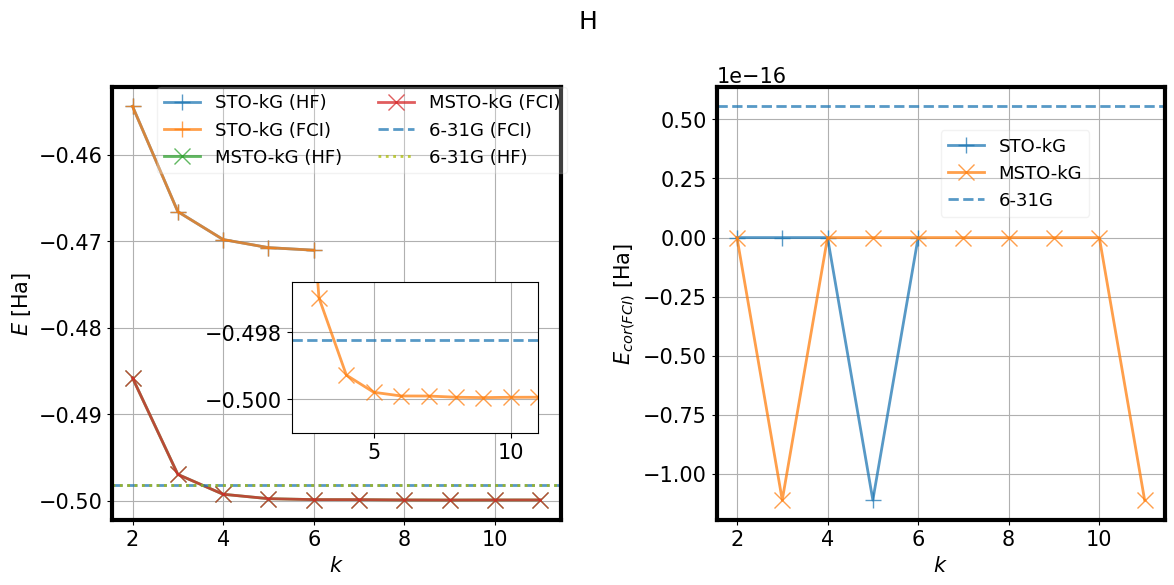

In [226]:
plotE(element='H', dirname = "./testdata/", prefix = "MOBS", \
          inset_xlim = [2,11], inset_ylim = [-0.501, -0.4965], \
          inset_loc = [0.4,0.2, 0.55, 0.35], legend = True)

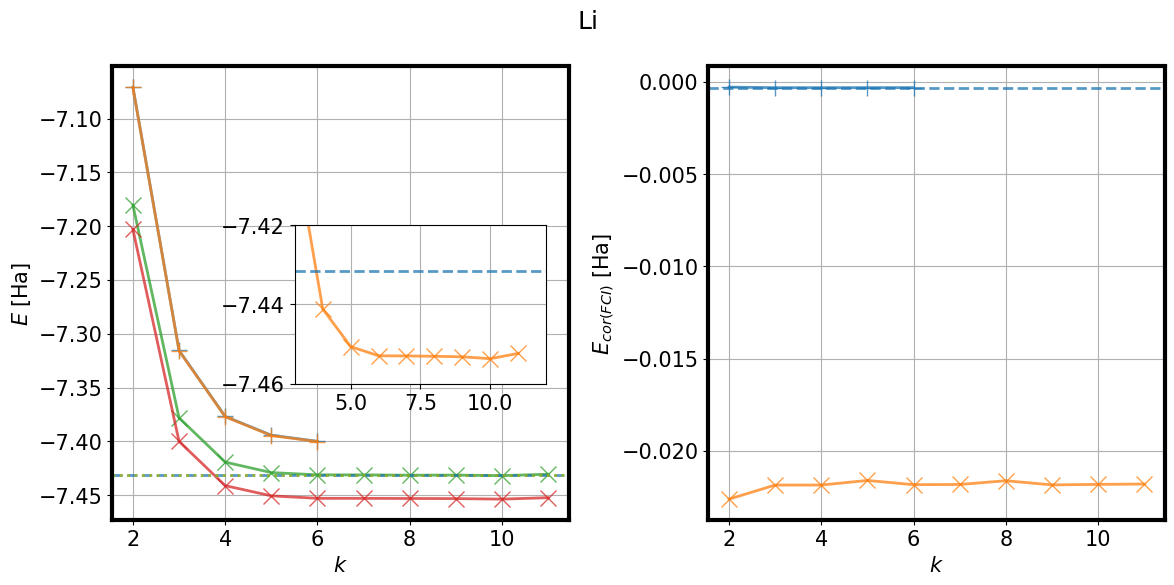

In [227]:
plotE(element='Li', dirname = "./testdata/", prefix = "MOBS", \
          inset_xlim=(3,12), inset_ylim=(-7.46,-7.42), \
          inset_loc = [0.4,0.3, 0.55, 0.35], legend = False)

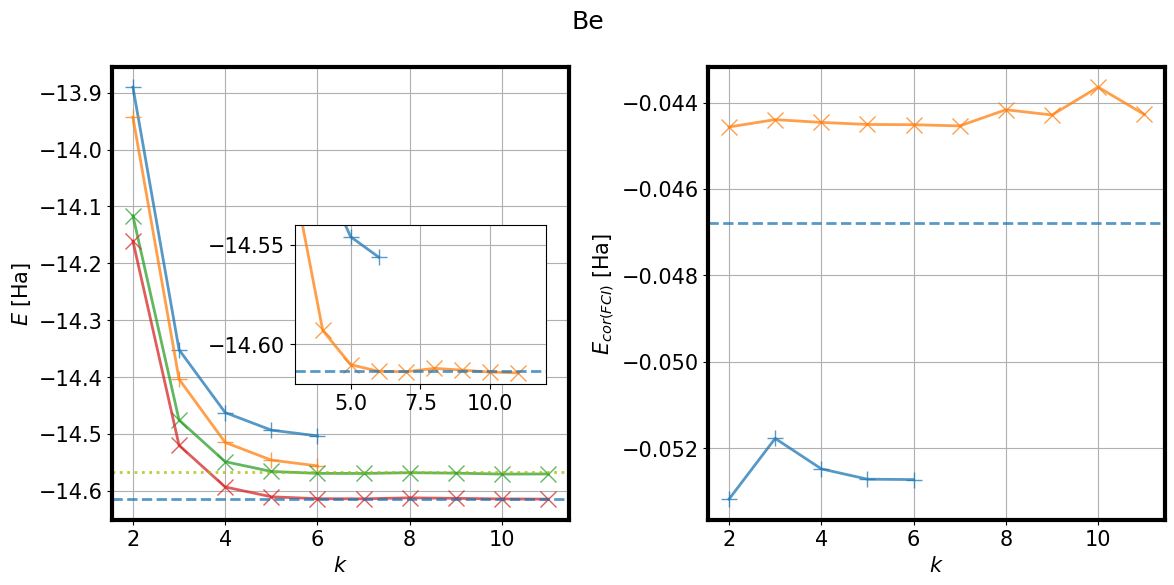

In [228]:
plotE(element='Be', dirname = "./testdata/", prefix = "MOBS", \
          inset_xlim=(3,12), inset_ylim=(-14.62,-14.54), \
          inset_loc = [0.4,0.3, 0.55, 0.35], legend = False)

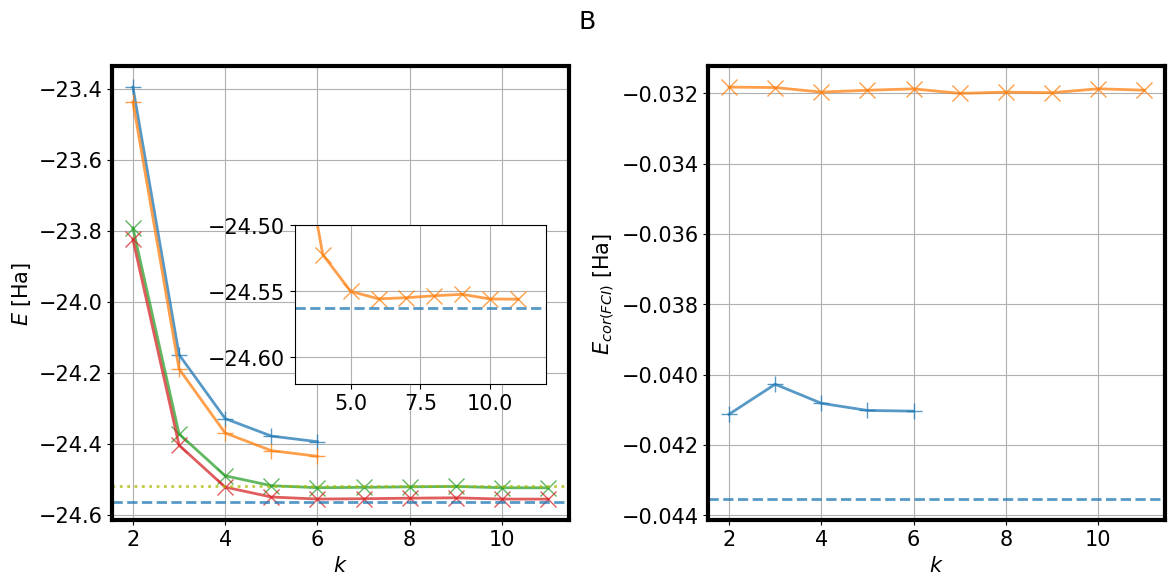

In [229]:
plotE(element='B', dirname = "./testdata/", prefix = "MOBS", \
          inset_xlim=(3,12), inset_ylim=(-24.62,-24.5), \
          inset_loc = [0.4,0.3, 0.55, 0.35], legend = False)

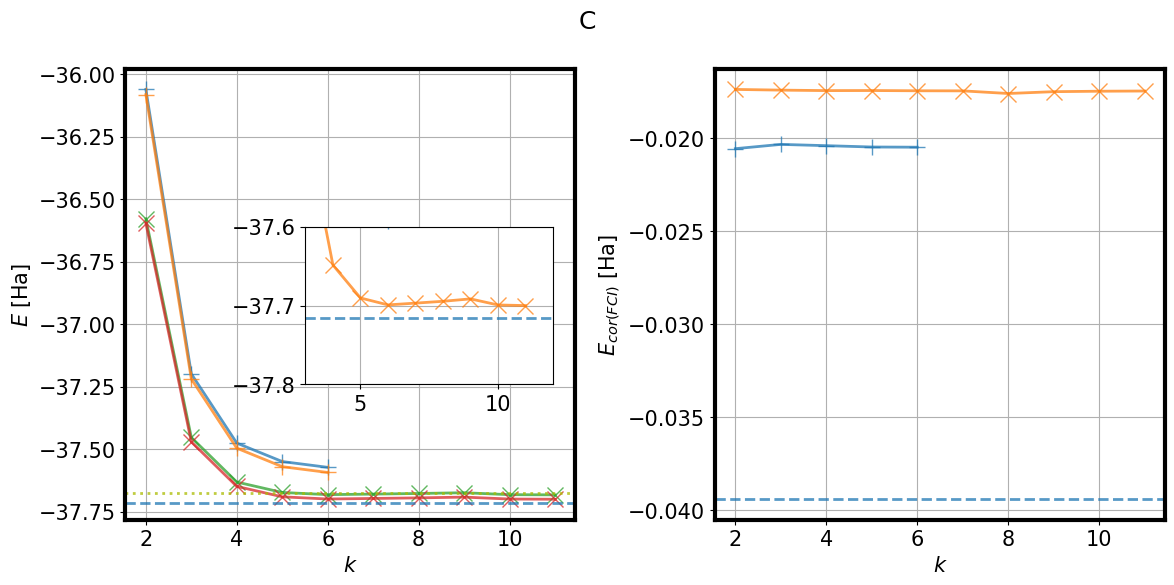

In [230]:
plotE(element='C', dirname = "./testdata/", prefix = "MOBS", \
          inset_xlim=(3,12), inset_ylim=(-37.8,-37.6), \
          inset_loc = [0.4,0.3, 0.55, 0.35], legend = False)

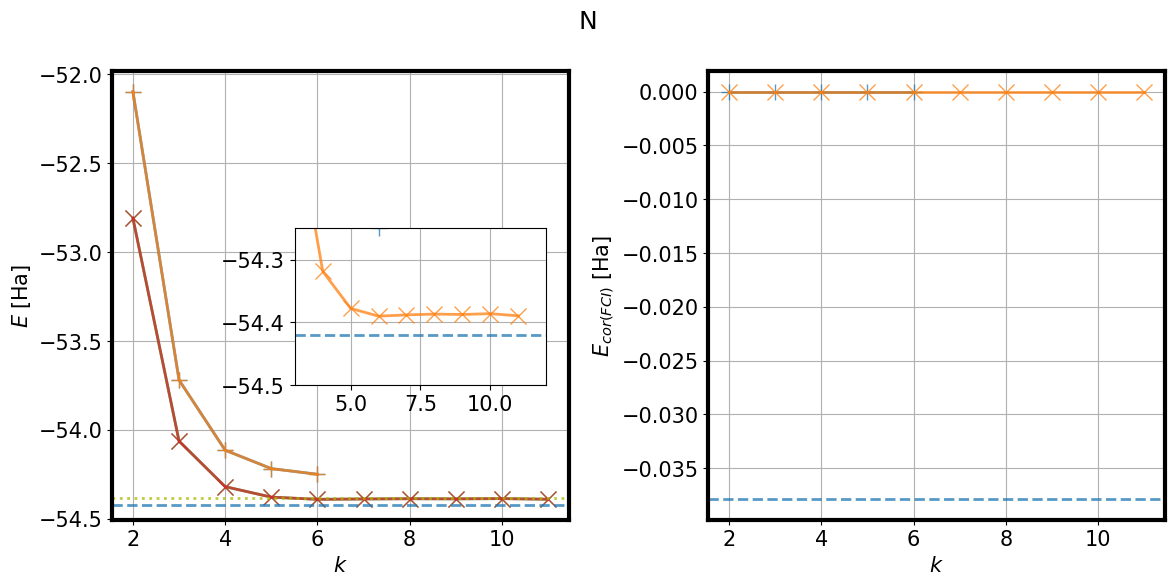

In [231]:
plotE(element='N', dirname = "./testdata/", prefix = "MOBS", \
          inset_xlim=(3,12), inset_ylim=(-54.5,-54.25), \
          inset_loc = [0.4,0.3, 0.55, 0.35], legend = False)

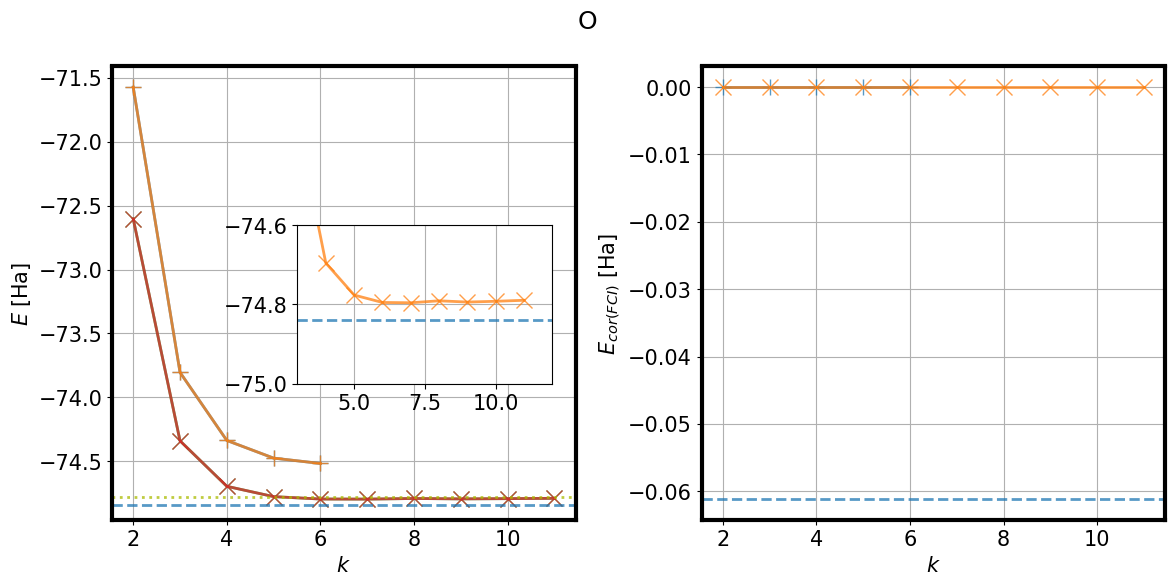

In [232]:
plotE(element='O', dirname = "./testdata/", prefix = "MOBS", \
          inset_xlim=(3,12), inset_ylim=(-75,-74.6), \
          inset_loc = [0.4,0.3, 0.55, 0.35], legend = False)

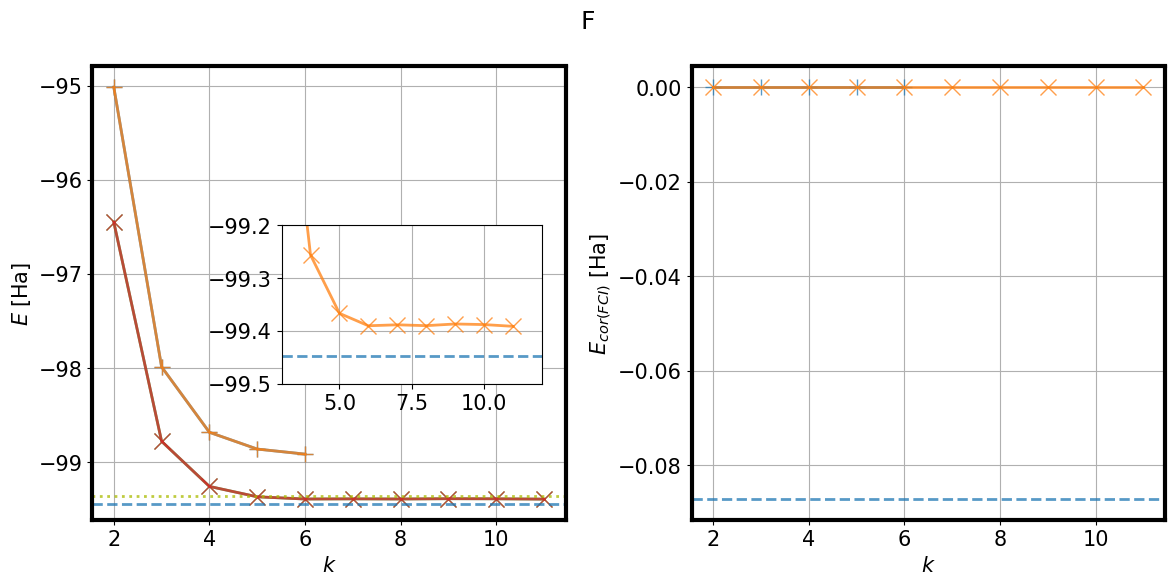

In [233]:
plotE(element='F', dirname = "./testdata/", prefix = "MOBS", \
          inset_xlim=(3,12), inset_ylim=(-99.5,-99.2), \
          inset_loc = [0.4,0.3, 0.55, 0.35], legend = False)

## Energy computation with different basis sets

In [244]:
from pyscf import gto, scf, fci

In [304]:
df = pd.DataFrame(columns=['Element', 'Basis', 'Energy (HF)', 'Energy (FCI)', 'Ecor (FCI)'])

In [305]:

basissets = ['sto-2g', 'sto-3g', 'sto-4g', 'sto-5g', 'sto-6g', '6-31g', '3-21g', 'MINI', 'MIDI']

# print(f"{'Basis':10s} | {'Energy (HF)':20s} | {'Energy (FCI)':20s}")
for element in 'H Li Be B C N O F'.split(' '):
    for basis in basissets:
    
        mol = moldict(basis)[element]
        mf = scf.RHF(mol).run(verbose=0)
        
        cisolver = fci.FCI(mf)
        energy, fcivec = cisolver.kernel()
        # print(f"{basis:10s} | {mf.e_tot:20.10f} | {energy:20.10f}")
        df.loc[len(df)] = [element, basis, mf.e_tot, energy, energy-mf.e_tot]
    
    for k in range(2,12):
        fname = os.path.join(dirname, f"{prefix}_{element}_msto-{k:02d}g.pickle")
        MSTO = loadBSI(fname)
        basis = f"MSTO-{k:02d}G"
        df.loc[len(df)] = [element, basis, MSTO['HF'], MSTO['FCI'][0], MSTO['FCI'][0]-MSTO['HF']]
        
        # print(f"{basis:10s} | {MSTO[k]['HF']:20.10f} | {MSTO[k]['FCI'][0]:20.10f}")



In [306]:
df.to_csv('EnergyComparison.csv')

<Figure size 640x480 with 0 Axes>

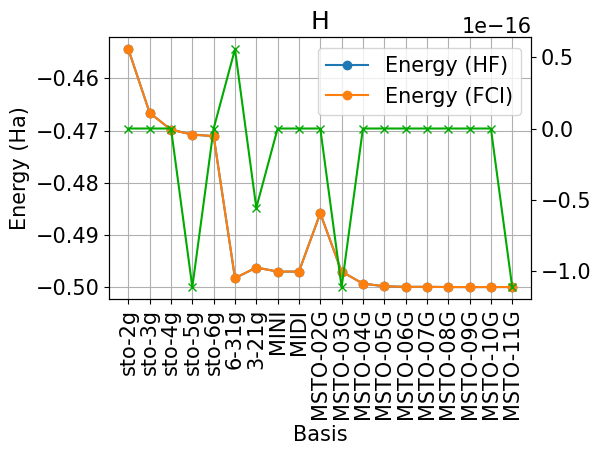

In [319]:
for element in 'H Li Be B C N O F'.split(' ')[:1]:
    pl.figure()
    df1 = df[df['Element']==element]
    ax = df1.plot(x='Basis', y=['Energy (HF)', 'Energy (FCI)'], marker='o', rot=90, label=['Energy (HF)', 'Energy (FCI)'])
    ax.set_xticks(range(len(df1)) )
    ax.set_xticklabels(df1['Basis'].values)
    ax.set_xlabel("Basis")
    ax.set_ylabel("Energy (Ha)")
    ax.set_title(element)
    ax.grid(True)

    ax2 = ax.twinx()
    df1.plot(x='Basis', y=['Ecor (FCI)'], marker='x', ax=ax2, color="#00aa00", label=['Ecor (FCI)'])

    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    handles = h1 + h2
    labels = l1 + l2
    ax1.legend(handles, labels, loc='best')
    ax2.legend().set_visible(False)
    pl.tight_layout()

In [28]:
df1 = pd.read_csv('EnergyComparison.csv')
df1

,Unnamed: 0,Element,Basis,Energy (HF),Energy (FCI),Ecor (FCI)
0,0,H,sto-2g,-0.454397,-0.454397,0.000000e+00
1,1,H,sto-3g,-0.466582,-0.466582,0.000000e+00
2,2,H,sto-4g,-0.469806,-0.469806,0.000000e+00
3,3,H,sto-5g,-0.470743,-0.470743,-1.110223e-16
4,4,H,sto-6g,-0.471039,-0.471039,0.000000e+00
...,...,...,...,...,...,...
147,147,F,MSTO-07G,-99.388497,-99.388497,-1.421085e-14
148,148,F,MSTO-08G,-99.390137,-99.390137,0.000000e+00
149,149,F,MSTO-09G,-99.386926,-99.386926,-2.842171e-14
150,150,F,MSTO-10G,-99.388069,-99.388069,0.000000e+00


In [25]:
df2 = pd.read_csv('Ecor.csv')
df2 = df2.drop(columns=['Unnamed: 0', 'Spin', 'ncas'])
df2 = df2[df2['Basis']=='ccpvdz']
df2 = df2.drop(columns=['Basis'])
tab = df2.to_latex(index=False)
tab = tab.replace(r'\toprule', r'\hline').replace(r'\midrule', r'\hline').replace(r'\bottomrule', r'\hline')

tab = r'''\begin{table}
'''+tab+r'''
\caption{Comparison of FCI energies for full active space $E(FCI)$ versus active space of 10 spin orbitals $E(asFCI)$.}
\end{table}
'''

print(tab)
df2

\begin{table}
\begin{tabular}{lrrrrrr}
\hline
Atom & E(HF) & E(asFCI) & Ecor(asFCI) & E(FCI) & Ecor(FCI) & Ecor_lost \\
\hline
B & -24.526591 & -24.545417 & -0.018826 & -24.590630 & -0.064039 & 70.601654 \\
C & -37.682418 & -37.694278 & -0.011860 & -37.761905 & -0.079487 & 85.079009 \\
N & -54.388414 & -54.388414 & 0.000000 & -54.480115 & -0.091701 & 100.000000 \\
O & -74.787513 & -74.787513 & -0.000000 & -74.911744 & -0.124231 & 100.000000 \\
F & -99.371862 & -99.371862 & 0.000000 & -99.529518 & -0.157656 & 100.000000 \\
\hline
\end{tabular}

\caption{Comparison of FCI energies for full active space $E(FCI)$ versus active space of 10 spin orbitals $E(asFCI)$.}
\end{table}



,Atom,E(HF),E(asFCI),Ecor(asFCI),E(FCI),Ecor(FCI),Ecor_lost
1,B,-24.526591,-24.545417,-1.882632e-02,-24.590630,-0.064039,70.601654
3,C,-37.682418,-37.694278,-1.186022e-02,-37.761905,-0.079487,85.079009
5,N,-54.388414,-54.388414,1.421085e-14,-54.480115,-0.091701,100.000000
7,O,-74.787513,-74.787513,-1.421085e-14,-74.911744,-0.124231,100.000000
9,F,-99.371862,-99.371862,0.000000e+00,-99.529518,-0.157656,100.000000


In [6]:

df1[df1['Element']=='B']

NameError: name 'df1' is not defined

In [1]:
from pyscf import gto, scf, fci, ao2mo
import numpy as np
import pandas as pd

df = pd.DataFrame(columns=["Atom", "Basis", "Spin", "E(HF)", "ncas", "E(asFCI)", "Ecor(asFCI)", "E(FCI)", "Ecor(FCI)", "Ecor_lost"])

spins = {'B': 1, 'C': 2, 'N': 3, 'O': 2, 'F': 1} 
atoms = ['B', 'C', 'N', 'O', 'F']

for atom_symbol in atoms:
    
    for basis in ['6-31g', 'ccpvdz']:
        print("\n*********")
        print(f"Atom: {atom_symbol}; Basis: {basis}")
        print("*******")

    
        mol = gto.M(atom=f'{atom_symbol} 0 0 0',
                    basis=basis,
                    spin=spins[atom_symbol],
                    charge=0,
                    unit='Bohr',
                    verbose=0)
        
        mf = scf.ROHF(mol)
        mf.conv_tol = 1e-10
        mf.kernel()
        hf_energy = mf.e_tot
        print("HF energy:", hf_energy)
    
        ncas = 5
        mo = mf.mo_coeff[:, :ncas]
        h1 = mo.T @ mf.get_hcore() @ mo
        eri = ao2mo.kernel(mol, mo)
        eri = ao2mo.restore(1, eri, ncas)
        nelec = mol.nelectron
        nelec_alpha = (nelec + mol.spin) // 2
        nelec_beta  = (nelec - mol.spin) // 2
    
        cisolver = fci.direct_spin1.FCI()
        E_fci, fcivec = cisolver.kernel(h1, eri, ncas, (nelec_alpha, nelec_beta))
    
        print("asFCI energy:", E_fci)
        print("asFCI Correlation energy:", E_fci - hf_energy) 
    
        yo = mf.mo_coeff 
        cisolver = fci.FCI(mol, yo)
        E_fcii, fciivec = cisolver.kernel() 
        print("FCI energy:", E_fcii) 
        print("FCI correlation energy:", E_fcii - hf_energy) 
    
        print("Percentage fraction of correl E lost:", ((E_fcii - E_fci)/(E_fcii - hf_energy))*100)
    # df = pd.DataFrame(columns=["Atom", "Spin", "E(HF)", "ncas", "E(asFCI)", "Ecor(asFCI)", "E(FCI)", "Ecor(FCI)", "Ecor_lost"])
        
        df.loc[len(df)] = [atom_symbol, basis, spins[atom_symbol], hf_energy, ncas, E_fci, E_fci - hf_energy, E_fcii, E_fcii - hf_energy, ((E_fcii - E_fci)/(E_fcii - hf_energy))*100]


*********
Atom: B; Basis: 6-31g
*******
HF energy: -24.519348011198478
asFCI energy: -24.54350789547413
asFCI Correlation energy: -0.024159884275650967
FCI energy: -24.56289176867274
FCI correlation energy: -0.04354375747426076
Percentage fraction of correl E lost: 44.51584870705711

*********
Atom: B; Basis: ccpvdz
*******
HF energy: -24.526590905983777
asFCI energy: -24.54541722260371
asFCI Correlation energy: -0.018826316619932726
FCI energy: -24.590629599935596
FCI correlation energy: -0.06403869395181871
Percentage fraction of correl E lost: 70.6016543152844

*********
Atom: C; Basis: 6-31g
*******
HF energy: -37.676865648283055
asFCI energy: -37.68990731737461
asFCI Correlation energy: -0.013041669091556685
FCI energy: -37.716264429242905
FCI correlation energy: -0.039398780959849944
Percentage fraction of correl E lost: 66.8982928562002

*********
Atom: C; Basis: ccpvdz
*******
HF energy: -37.68241788145876
asFCI energy: -37.69427810382393
asFCI Correlation energy: -0.011860222

In [2]:
df

,Atom,Basis,Spin,E(HF),ncas,E(asFCI),Ecor(asFCI),E(FCI),Ecor(FCI),Ecor_lost
0,B,6-31g,1,-24.519348,5,-24.543508,-2.415988e-02,-24.562892,-0.043544,44.515849
1,B,ccpvdz,1,-24.526591,5,-24.545417,-1.882632e-02,-24.590630,-0.064039,70.601654
2,C,6-31g,2,-37.676866,5,-37.689907,-1.304167e-02,-37.716264,-0.039399,66.898293
3,C,ccpvdz,2,-37.682418,5,-37.694278,-1.186022e-02,-37.761905,-0.079487,85.079009
4,N,6-31g,3,-54.382051,5,-54.382051,2.131628e-14,-54.419940,-0.037889,100.000000
5,N,ccpvdz,3,-54.388414,5,-54.388414,1.421085e-14,-54.480115,-0.091701,100.000000
6,O,6-31g,2,-74.778234,5,-74.778234,1.421085e-14,-74.839408,-0.061174,100.000000
7,O,ccpvdz,2,-74.787513,5,-74.787513,-1.421085e-14,-74.911744,-0.124231,100.000000
8,F,6-31g,1,-99.360218,5,-99.360218,2.842171e-14,-99.447423,-0.087205,100.000000
9,F,ccpvdz,1,-99.371862,5,-99.371862,0.000000e+00,-99.529518,-0.157656,100.000000


In [3]:
df.to_csv('Ecor.csv')

In [181]:




def plotE(element='H', \
          inset_xlim = [2,11], inset_ylim = [-0.501, -0.4965], \
          inset_loc = [0.4,0.2, 0.55, 0.35], legend = True):
    
    df_E = pd.read_csv('EnergyComparison.csv')
    df_Ecor = pd.read_csv('Ecor.csv')
    
    df_E = df_E[df_E['Element']==element]#
    try:
        df_Ecor = df_Ecor[df_Ecor['Atom']==element]#
    except:
        pass
        
    sto = df_E[df_E['Basis'].str.contains('^sto-') ]
    ksto = range(2,7)
    sto.insert(loc=len(sto.columns), column='k', value=list(ksto))
    
    msto = df_E[df_E['Basis'].str.contains('^MSTO-') ]
    kmsto = range(2,12)
    msto.insert(loc=len(msto.columns), column='k', value=list(kmsto))
    
    fig = pl.figure(figsize=(10,5))
    ax0 = fig.add_subplot(1,2,1)
    ax1 = fig.add_subplot(1,2,2)
    
    ax0.plot(sto['k'], sto['Energy (HF)'], 'x--', label='STO (HF)', alpha=0.5)
    ax0.plot(msto['k'], msto['Energy (HF)'], 'x--', label='MSTO (HF)', alpha=0.5)
    
    ax0.plot(sto['k'], sto['Energy (FCI)'], 'o-', label='STO (FCI)', markerfacecolor='none', alpha=0.5)
    ax0.plot(msto['k'], msto['Energy (FCI)'], 'o-', label='MSTO (FCI)', markerfacecolor='none', alpha=0.5)
    
    ax0.axhline(y=df_E[df_E['Basis']=='6-31g']['Energy (HF)'].values[0], linestyle='dashed', color='#aaaa00', label='6-31g (HF)', alpha=0.5)
    ax0.axhline(y=df_E[df_E['Basis']=='6-31g']['Energy (FCI)'].values[0], color='#00aaaa', label='6-31g (FCI)', alpha=0.5)
    
    
    ax0.grid(True)
    ax0yax_color='black'
    ax0.set_xlabel(r'$k$')
    ax0.set_ylabel(r'$E$ [Ha]', color=ax0yax_color)
    ax0.spines['left'].set_color(ax0yax_color)
    ax0.tick_params(axis='y', labelcolor=ax0yax_color)
    
    
    #inset
    axins = ax0.inset_axes(inset_loc, xlim=inset_xlim, ylim=inset_ylim)
    axins.plot(sto['k'], sto['Energy (HF)'], 'x--', alpha=0.5)
    axins.plot(msto['k'], msto['Energy (HF)'], 'x--', alpha=0.5)
    
    axins.plot(sto['k'], sto['Energy (FCI)'], 'o-', markerfacecolor='none', alpha=0.5)
    axins.plot(msto['k'], msto['Energy (FCI)'], 'o-', markerfacecolor='none', alpha=0.5)
    
    axins.axhline(y=df_E[df_E['Basis']=='6-31g']['Energy (HF)'].values[0], linestyle='dashed', color='#aaaa00', alpha=0.5)
    axins.axhline(y=df_E[df_E['Basis']=='6-31g']['Energy (FCI)'].values[0], color='#00aaaa', alpha=0.5)
    
    axins.grid(True)
    
    ax1.plot(sto['k'], sto['Ecor (FCI)'], 'o-', label='STO [Ecor(FCI)]', markerfacecolor='none', alpha=0.5)
    ax1.plot(msto['k'], msto['Ecor (FCI)'], 'o-', label='MSTO [Ecor(FCI)]', markerfacecolor='none', alpha=0.5)
    
    
    if element in df_Ecor['Atom'].values:
        # ax1.axhline(y=df_Ecor[df_Ecor['Basis']=='ccpvdz' and df_Ecor['Atom']==element]['Ecor(asFCI)'].values[0], label='ccpvdz [Ecor(asFCI)]', alpha=0.5)
        # ax1.axhline(y=df_Ecor[df_Ecor['Basis']=='ccpvdz' and df_Ecor['Atom']==element]['Ecor(FCI)'].values[0], label='ccpvdz [Ecor(FCI)]', alpha=0.5)
        ax1.axhline(y=df_Ecor[df_Ecor['Basis']=='ccpvdz']['Ecor(FCI)'].values[0], label='ccpvdz [Ecor(FCI)]', color='#00ff00', alpha=0.5)
        ax1.axhline(y=df_Ecor[df_Ecor['Basis']=='ccpvdz']['Ecor(asFCI)'].values[0], label='ccpvdz [Ecor(asFCI)]', color='#ff0000', alpha=0.5)
    
    ax1.grid(True)
    ax1yax_color='black'
    ax1.set_xlabel(r'$k$')
    ax1.set_ylabel(r'$E_{cor}$ [Ha]', color=ax1yax_color)
    ax1.spines['left'].set_color(ax1yax_color)
    ax1.tick_params(axis='y', labelcolor=ax1yax_color)
    if legend:
        ax0.legend(fontsize=12, labelcolor=ax0yax_color, ncols=2, loc=(0.1, 0.7), framealpha=0.75)
        ax1.legend(fontsize=12, labelcolor=ax1yax_color)
    
    for side in ['top', 'bottom', 'left', 'right']:
            ax1.spines[side].set_linewidth(3)
            ax0.spines[side].set_linewidth(3)

    fig.suptitle(f"{element}")
    fig.tight_layout()
    fig.savefig(f"{element}.png", dpi=300)

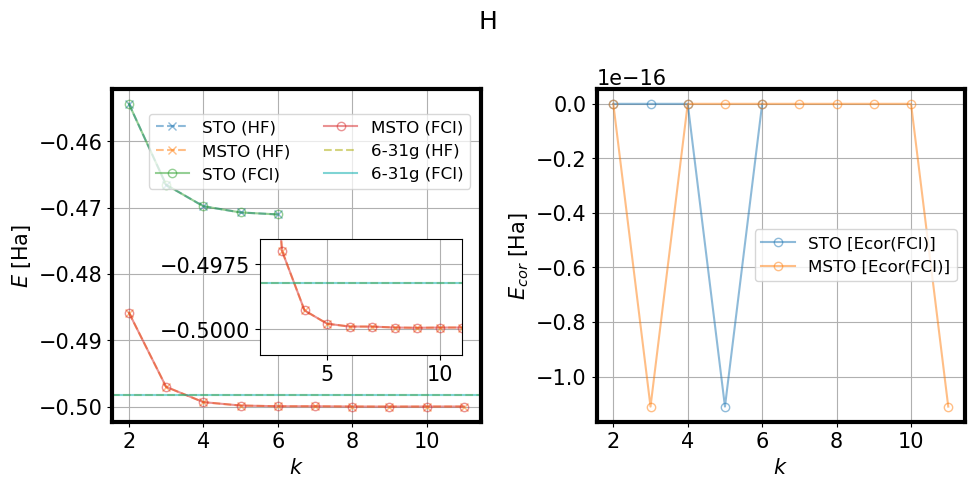

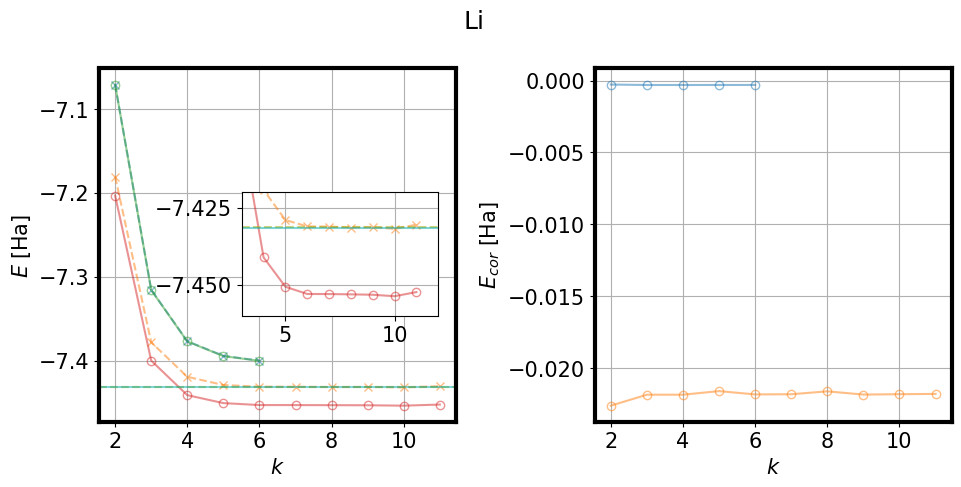

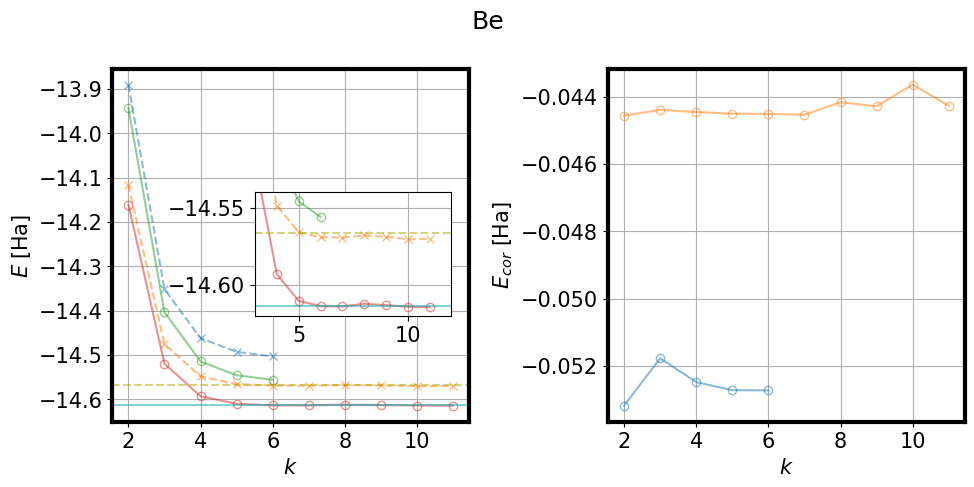

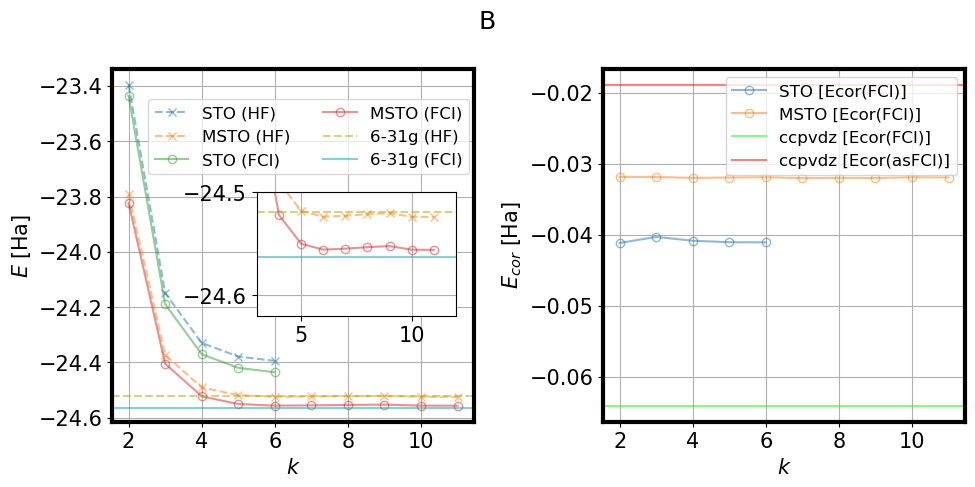

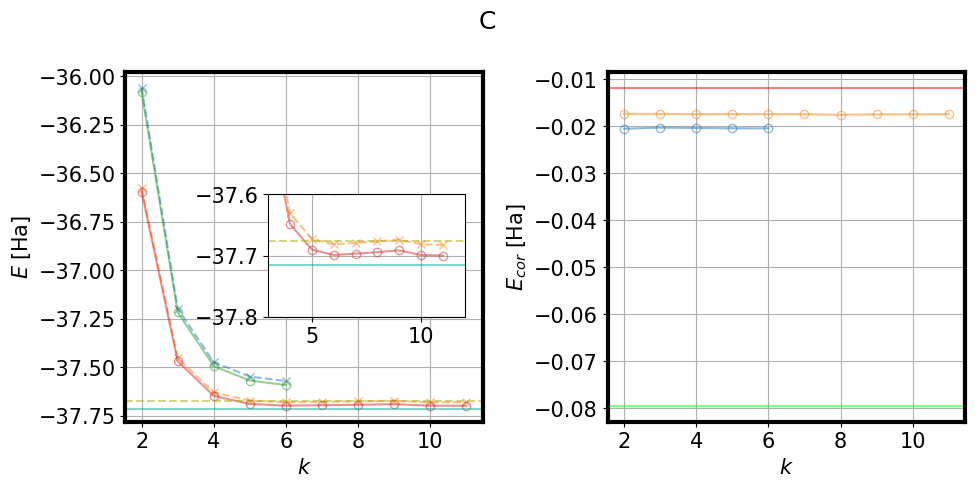

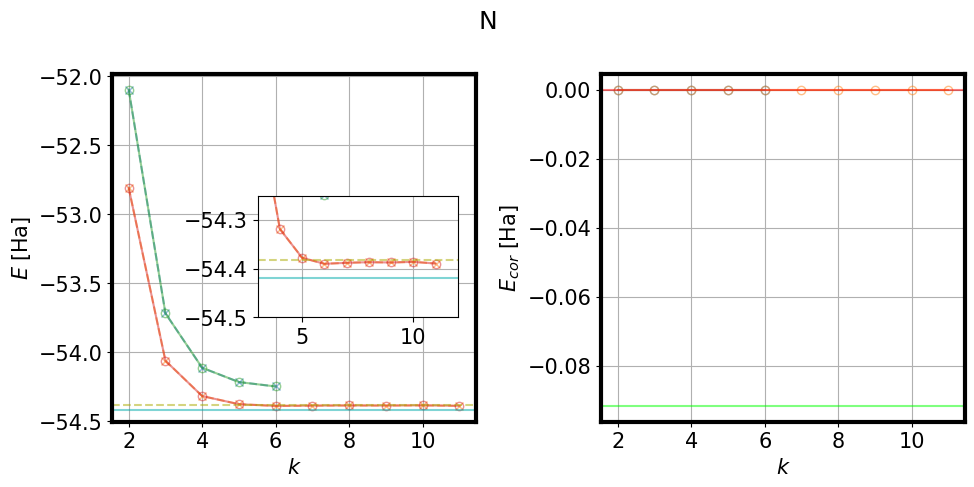

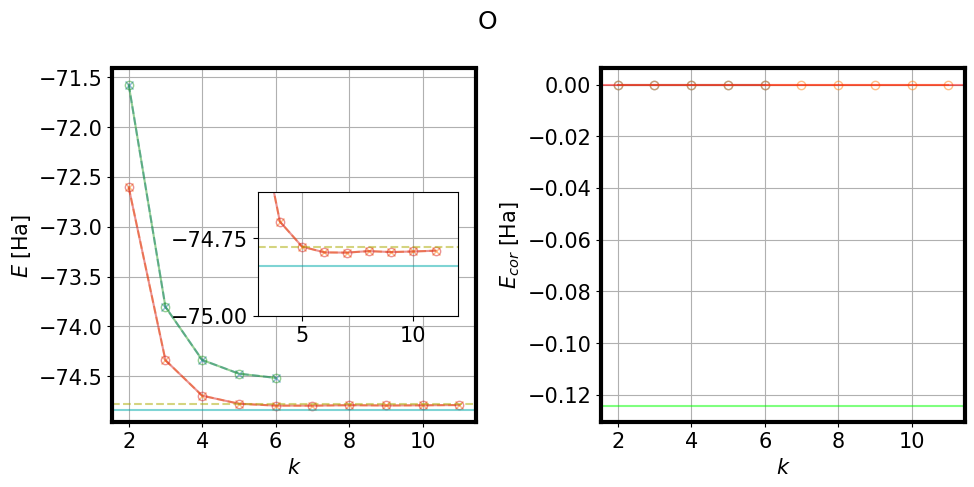

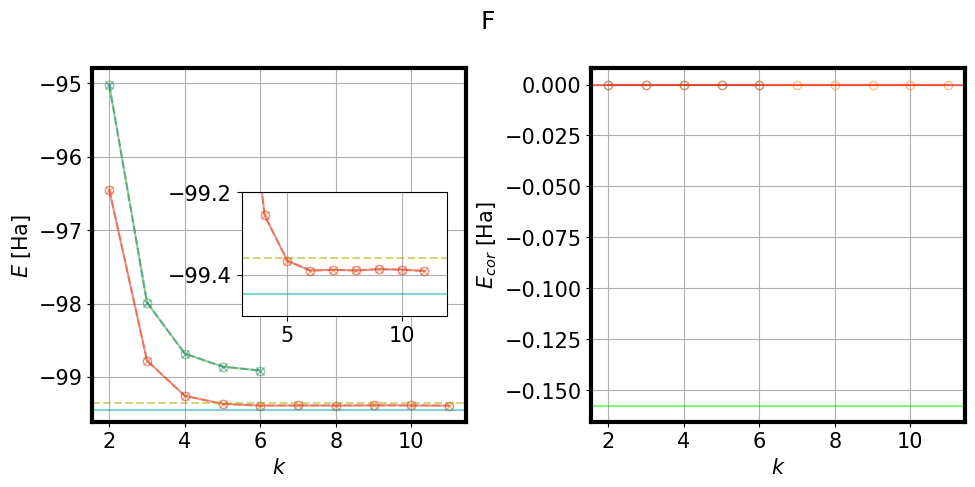

In [182]:
plotE(element='H',  \
          inset_xlim = [2,11], inset_ylim = [-0.501, -0.4965], \
          inset_loc = [0.4,0.2, 0.55, 0.35], legend = True)

plotE(element='Li',  \
          inset_xlim=(3,12), inset_ylim=(-7.46,-7.42), \
          inset_loc = [0.4,0.3, 0.55, 0.35], legend = False)
          
plotE(element='Be',  \
          inset_xlim=(3,12), inset_ylim=(-14.62,-14.54), \
          inset_loc = [0.4,0.3, 0.55, 0.35], legend = False)
          
plotE(element='B',  \
          inset_xlim=(3,12), inset_ylim=(-24.62,-24.5), \
          inset_loc = [0.4,0.3, 0.55, 0.35], legend = True)
          
plotE(element='C',  \
          inset_xlim=(3,12), inset_ylim=(-37.8,-37.6), \
          inset_loc = [0.4,0.3, 0.55, 0.35], legend = False)

plotE(element='N',  \
          inset_xlim=(3,12), inset_ylim=(-54.5,-54.25), \
          inset_loc = [0.4,0.3, 0.55, 0.35], legend = False)
          
plotE(element='O',  \
          inset_xlim=(3,12), inset_ylim=(-75,-74.6), \
          inset_loc = [0.4,0.3, 0.55, 0.35], legend = False)
          
plotE(element='F',  \
          inset_xlim=(3,12), inset_ylim=(-99.5,-99.2), \
          inset_loc = [0.4,0.3, 0.55, 0.35], legend = False)
          


## Tables